# Titanic — Decision Tree & Random Forest


**Import libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 110

print("Libraries loaded.")

Libraries loaded.


**Load the dataset**

In [2]:
df = pd.read_csv("train.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


**Check data types and missing values**

In [3]:
print(df.shape)
df.info()

(891, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [4]:
missing = df.isnull().sum()
print("Missing values per column:")
print(missing[missing > 0].to_string())

Missing values per column:
Age         177
Cabin       687
Embarked      2


**Target distribution**

In [5]:
print(df['Survived'].value_counts())
print()
print(f"Survival rate: {df['Survived'].mean():.2%}")

Survived
0    549
1    342
Name: count, dtype: int64

Survival rate: 38.38%


**EDA — survival by sex and class**

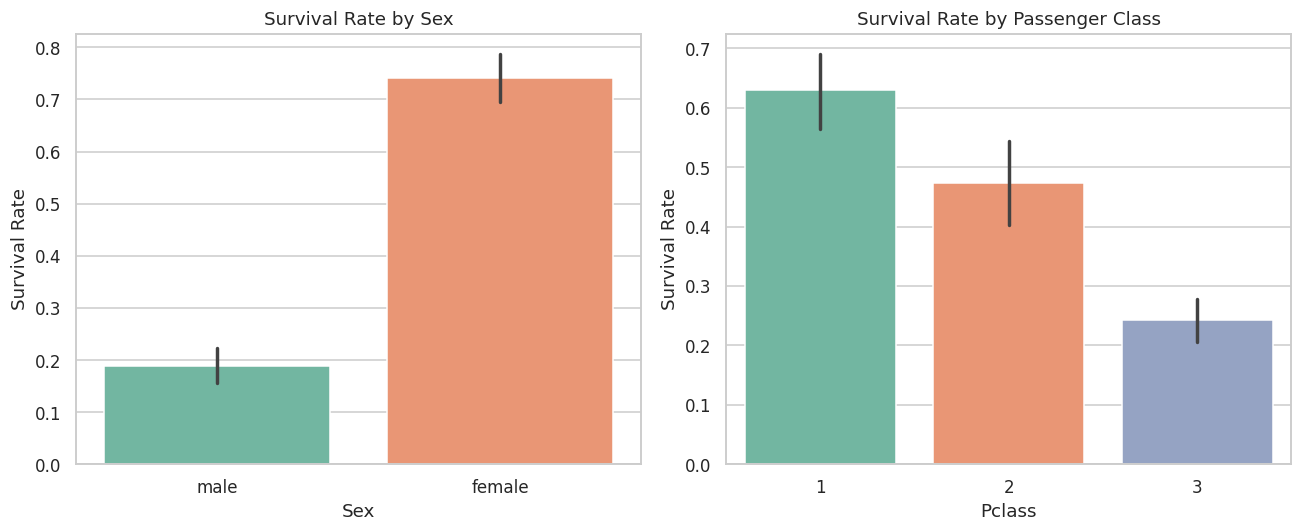

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.barplot(x='Sex', y='Survived', data=df, ax=axes[0], palette='Set2')
axes[0].set_title('Survival Rate by Sex')
axes[0].set_ylabel('Survival Rate')

sns.barplot(x='Pclass', y='Survived', data=df, ax=axes[1], palette='Set2')
axes[1].set_title('Survival Rate by Passenger Class')
axes[1].set_ylabel('Survival Rate')

plt.tight_layout()
plt.show()

**EDA — age distribution and correlation**

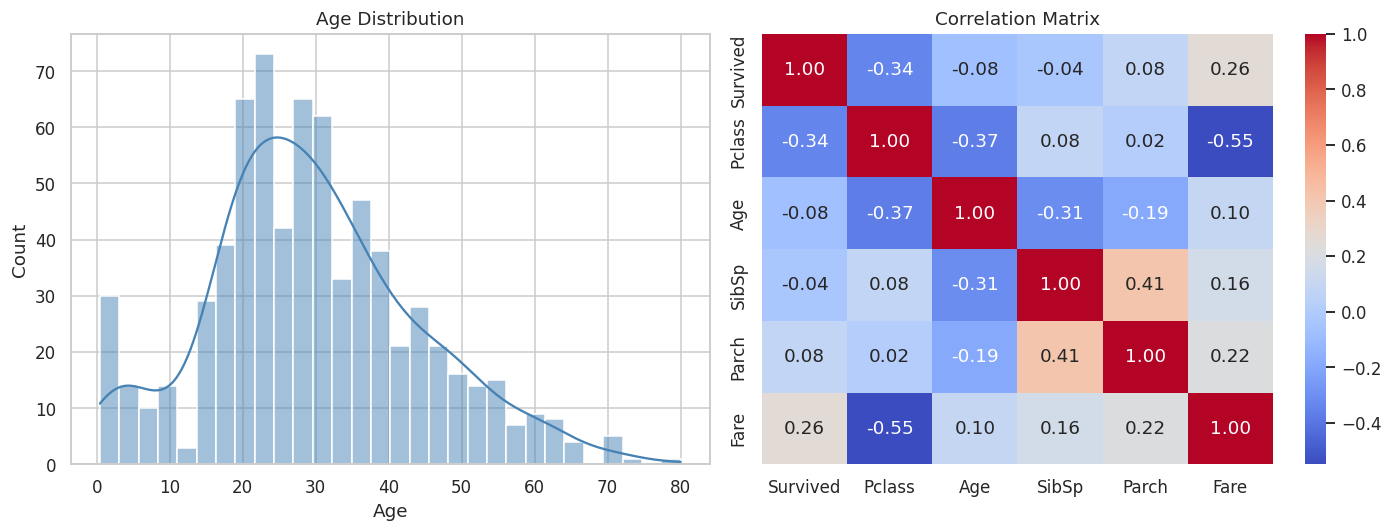

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.histplot(df['Age'].dropna(), bins=30, kde=True, color='steelblue', ax=axes[0])
axes[0].set_title('Age Distribution')

numeric_cols = ['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', ax=axes[1])
axes[1].set_title('Correlation Matrix')

plt.tight_layout()
plt.show()

**Preprocessing**

- Drop columns that aren't useful as model features: `PassengerId`, `Name`, `Ticket`, `Cabin` (Cabin is missing for most rows)
- Fill missing `Age` with the median, missing `Embarked` with the mode
- Encode `Sex` and `Embarked` as numbers

In [8]:
df_clean = df.drop(columns=['PassengerId', 'Name', 'Ticket', 'Cabin'])

df_clean['Age'] = df_clean['Age'].fillna(df_clean['Age'].median())
df_clean['Embarked'] = df_clean['Embarked'].fillna(df_clean['Embarked'].mode()[0])

df_clean['Sex'] = df_clean['Sex'].map({'male': 0, 'female': 1})
df_clean['Embarked'] = df_clean['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})

print("Missing values after cleaning:", df_clean.isnull().sum().sum())
df_clean.head()

Missing values after cleaning: 0


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,0,22.0,1,0,7.2500,0
1,1,1,1,38.0,1,0,71.2833,1
2,1,3,1,26.0,0,0,7.9250,0
3,1,1,1,35.0,1,0,53.1000,0
4,0,3,0,35.0,0,0,8.0500,0


**Train/test split**

In [9]:
X = df_clean.drop(columns=['Survived'])
y = df_clean['Survived']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set:     {X_test.shape[0]} samples")

Training set: 712 samples
Test set:     179 samples


## Decision Tree

In [10]:
dt = DecisionTreeClassifier(max_depth=5, min_samples_split=10, random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)
acc_dt = accuracy_score(y_test, y_pred_dt)

print(f"Decision Tree accuracy: {acc_dt:.4f}")
print()
print(classification_report(y_test, y_pred_dt, target_names=['Did not survive', 'Survived']))

Decision Tree accuracy: 0.7821

                 precision    recall  f1-score   support

Did not survive       0.79      0.88      0.83       110
       Survived       0.77      0.62      0.69        69

       accuracy                           0.78       179
      macro avg       0.78      0.75      0.76       179
   weighted avg       0.78      0.78      0.78       179



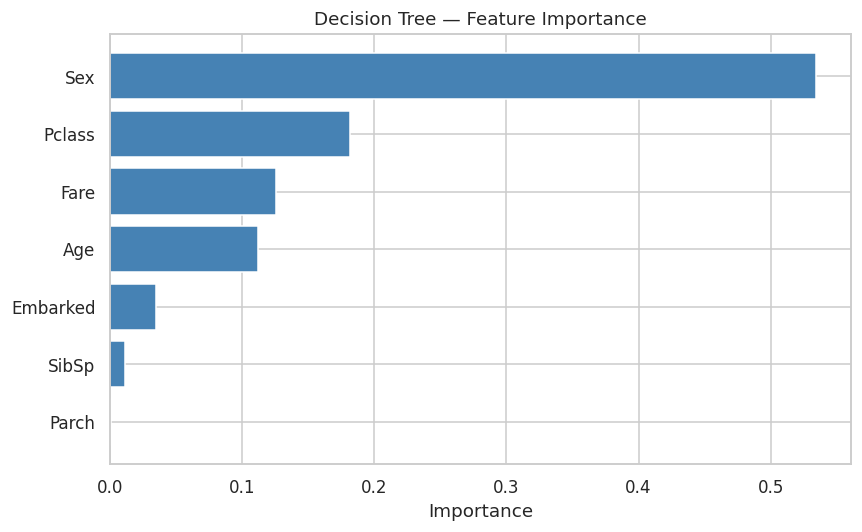

In [11]:
feat_imp_dt = pd.DataFrame({
    'Feature': X.columns,
    'Importance': dt.feature_importances_
}).sort_values('Importance', ascending=True)

plt.figure(figsize=(8, 5))
plt.barh(feat_imp_dt['Feature'], feat_imp_dt['Importance'], color='steelblue')
plt.xlabel('Importance')
plt.title('Decision Tree — Feature Importance')
plt.tight_layout()
plt.show()

## Random Forest

In [12]:
rf = RandomForestClassifier(n_estimators=200, max_depth=6, min_samples_split=10, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
acc_rf = accuracy_score(y_test, y_pred_rf)

print(f"Random Forest accuracy: {acc_rf:.4f}")
print()
print(classification_report(y_test, y_pred_rf, target_names=['Did not survive', 'Survived']))

Random Forest accuracy: 0.8156

                 precision    recall  f1-score   support

Did not survive       0.80      0.93      0.86       110
       Survived       0.85      0.64      0.73        69

       accuracy                           0.82       179
      macro avg       0.82      0.78      0.79       179
   weighted avg       0.82      0.82      0.81       179



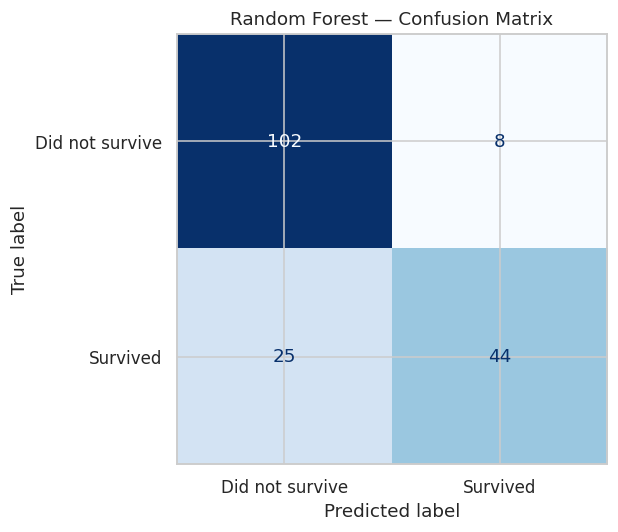

In [13]:
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Did not survive', 'Survived'])
disp.plot(cmap='Blues', ax=ax, colorbar=False)
ax.set_title('Random Forest — Confusion Matrix')
plt.tight_layout()
plt.show()

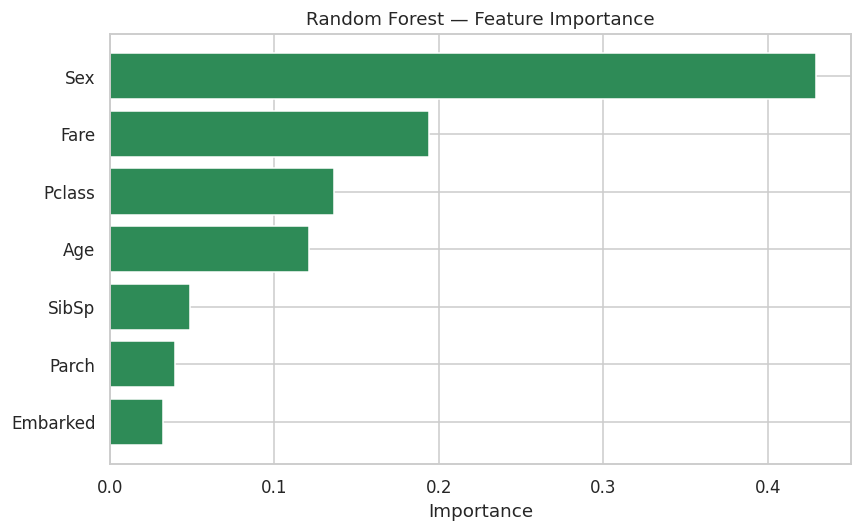

In [14]:
feat_imp_rf = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=True)

plt.figure(figsize=(8, 5))
plt.barh(feat_imp_rf['Feature'], feat_imp_rf['Importance'], color='seagreen')
plt.xlabel('Importance')
plt.title('Random Forest — Feature Importance')
plt.tight_layout()
plt.show()

**Cross-validation (5-fold)**

In [15]:
cv_scores = cross_val_score(rf, X, y, cv=5, scoring='accuracy')

print("5-Fold CV accuracy scores:", cv_scores.round(4))
print(f"Mean: {cv_scores.mean():.4f}   Std: {cv_scores.std():.4f}")

5-Fold CV accuracy scores: [0.7877 0.8258 0.8427 0.7921 0.8652]
Mean: 0.8227   Std: 0.0296


**Hyperparameter tuning (Grid Search)**

In [16]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [4, 6, 8, None],
    'min_samples_split': [2, 10],
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)
grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
print(f"Best CV accuracy: {grid_search.best_score_:.4f}")

best_rf = grid_search.best_estimator_
y_pred_best = best_rf.predict(X_test)
print(f"Test accuracy with best model: {accuracy_score(y_test, y_pred_best):.4f}")

Best parameters: {'max_depth': None, 'min_samples_split': 10, 'n_estimators': 200}
Best CV accuracy: 0.8246
Test accuracy with best model: 0.8156


## Summary

- Decision Tree and Random Forest were both trained to predict `Survived`.
- Random Forest generally outperforms a single Decision Tree because it averages many trees trained on bootstrapped samples with random feature subsets, which reduces variance/overfitting.
- `Sex`, `Pclass`, and `Fare` are consistently the most important features — matches what's known historically ("women and children first", higher class passengers had better access to lifeboats).